In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import torch

import gamex_cascades as gx      # the classical side: geometry, EM, the fitted process
import gamex_transformer as gt   # the network: heads, loss, training, generation

SEED = 123
torch.manual_seed(SEED)
device = torch.device("cpu")   # ~120k parameters: a GPU would not help

print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.7.1
Device: cpu


# Real Cascades, Learned by a Transformer

**Edinburgh Summer School on Generative AI for Extremes — 10 September 2026**

**Suggested time for this Notebook:** 30 minutes

Practical 4 built the extreme Hawkes process from a known truth. Here the three series are real — thirty-eight years of S&P 500, DAX and Nikkei returns — and **the cascades are never observed**.

The continuous Transformer estimates the marked Hawkes parameters autoregressively; the estimates recover the latent cascades, and the same network generates new crises event by event. The classical machinery is in `gamex_cascades.py` (`gx`) and the network in `gamex_transformer.py` (`gt`).

## Learning goals

By the end you should be able to:

- put three real markets on the Laplace scale and find their extreme days;
- place $\tilde\eta$, $\tilde\beta$, $\tilde\kappa$ and $g_\psi$ inside the Transformer's heads;
- write the likelihood of a cascade and maximise it by gradient descent;
- read the parameter estimates off the trained model;
- recover the latent cascades at the Transformer's estimates;
- generate new crises, and watch one being built event by event;
- judge the generated cascades with three simple checks.

## 1. Three markets, thirty-eight years

Daily closes of the three indices are cached in the repository. We work with log returns, fit on the years before the split and test on what came after,

$$
\mathrm{split} = \text{2018-01-01},
\qquad
q = 0.90,
\qquad
\alpha = 1.
$$

The moves cluster in time and often across markets; the dotted line is the split.

In [2]:
SPLIT = "2018-01-01"         # everything before this is used to fit; the rest is a test
Q_LEVEL = 0.90               # one day in ten counts as extreme, in its own direction
alpha = 1.0                  # exceedances above the quantile are exponential (appendix)
C1 = -np.log(1.0 - Q_LEVEL)  # the model's own cut, unused once u_q_theta is given
EPOCHS = 30
BATCH_SIZE = 128

prices = pd.read_csv("data/indices.csv", index_col=0, parse_dates=True)
returns = np.log(prices).diff().dropna()
is_train = np.asarray(returns.index < SPLIT)

print(len(returns), "common trading days,", returns.index[0].date(), "to", returns.index[-1].date())
print("Training days:", int(is_train.sum()), "| test days:", int((~is_train).sum()))

9009 common trading days, 1988-01-05 to 2026-08-24
Training days: 7006 | test days: 2003


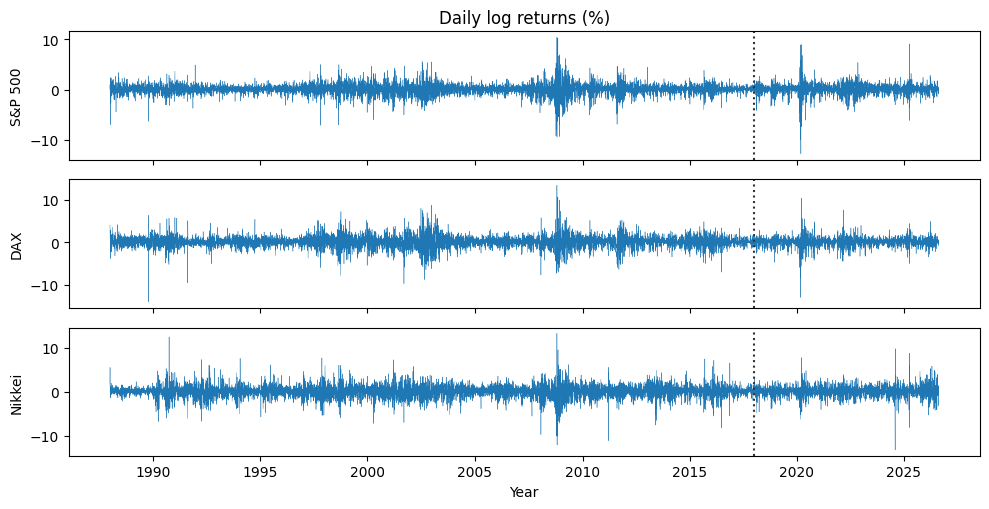

In [3]:
names = {"SP500": "S&P 500", "DAX": "DAX", "Nikkei": "Nikkei"}
years = pd.date_range("1990-01-01", returns.index[-1], freq="5YS")
ticks = [np.searchsorted(returns.index, y) for y in years]
split_at = np.searchsorted(returns.index, pd.Timestamp(SPLIT))

fig, axes = plt.subplots(3, 1, figsize=(10, 5.2), sharex=True)
for ax, col in zip(axes, returns.columns):
    ax.plot(100 * returns[col].to_numpy(), lw=0.3)
    ax.axvline(split_at, color="0.2", ls=":")
    ax.set_ylabel(names[col])
axes[-1].set_xticks(ticks, [y.year for y in years])
axes[-1].set_xlabel("Year")
axes[0].set_title("Daily log returns (%)")
plt.tight_layout()
plt.show()

## 2. The Laplace cloud and the extreme days

Each series is ranked within the training years and mapped to standard Laplace margins,

$$
E = \begin{cases} \log(2U), & U < 1/2, \\ -\log\{2(1 - U)\}, & U \ge 1/2, \end{cases}
\qquad
U = \hat F_{\mathrm{train}}(X),
$$

so every day is a mark $E_t = R_t W_t$ in $\mathbb{R}^3$.

The quantile is now estimated, $\hat u_q(w) = \exp\{\phi(w)^\top \theta\}$, by quantile regression of $\log R$ on nine functions of the direction (appendix). **An extreme day lies outside its own direction's quantile**, $R > \hat u_q(W)$.

In [4]:
# ranks come from the training years only: nothing after 2017 touches the transform
E = gx.laplace_from_train(returns, SPLIT)
X = E.to_numpy()
R = np.linalg.norm(X, axis=1)   # how far the day went
W = X / R[:, None]              # and in which direction

# a threshold that depends on the direction, fitted as a linear programme
u_q, theta_qr = gx.fit_quantile_threshold(R[is_train], W[is_train], Q_LEVEL)
extreme = R > u_q(W)        # the definition of an extreme day, in one line
m_train, m_test = extreme & is_train, extreme & ~is_train

print("Training coverage of the quantile surface:",
      f"{np.mean(R[is_train] <= u_q(W[is_train])):.4f}", f"(q = {Q_LEVEL})")
print("Extreme days | training:", int(m_train.sum()), "| test:", int(m_test.sum()))

Training coverage of the quantile surface: 0.8998 (q = 0.9)
Extreme days | training: 702 | test: 148


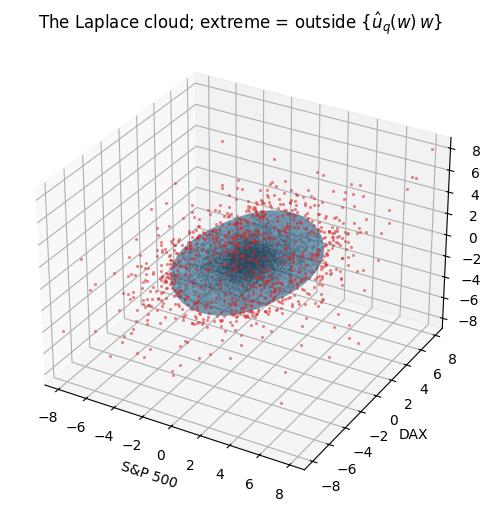

In [5]:
fig = plt.figure(figsize=(7.5, 6))
ax = fig.add_subplot(projection="3d")
gx.star_surface(ax, gx.surface_of(u_q), colour="C0", alpha=0.35)
ax.scatter(X[~extreme, 0], X[~extreme, 1], X[~extreme, 2], s=2, alpha=0.2, color="0.3", linewidths=0)
ax.scatter(X[extreme, 0], X[extreme, 1], X[extreme, 2], s=5, color="C3", alpha=0.55,
           linewidths=0, depthshade=False)
lim = 1.1 * np.abs(X[extreme]).max()
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
ax.set_xlabel("S&P 500")
ax.set_ylabel("DAX")
ax.set_zlabel("Nikkei")
ax.set_title(r"The Laplace cloud; extreme = outside $\{\hat u_q(w)\, w\}$")
plt.show()

## 3. The Transformer estimates the process

Write the history as $\mathcal{H}_i = \{(T_1, X_1), \ldots, (T_i, X_i)\}$, with $X_j = R_j W_j$ and $\Delta T_{i+1} = T_{i+1} - T_i$. The next event factorises into four questions,

$$
p\big(T_{i+1}, W_{i+1}, R_{i+1} \,\big|\, \mathcal{H}_i\big)
= \mathbb{P}\big(C_i = 1 \,\big|\, \mathcal{H}_i\big)\;
  f\big(\Delta T_{i+1} \,\big|\, \mathcal{H}_i\big)\;
  f\big(W_{i+1} \,\big|\, \Delta T_{i+1},\, \mathcal{H}_i\big)\;
  f\big(R_{i+1} \,\big|\, W_{i+1}\big),
$$

where $C_i = 1$ means the cascade continues. The Transformer carries **one head per factor**, and parameters it estimates are written with a tilde. With the excitation $A_i = \sum_{j \le i} e^{-\tilde\beta (T_i - T_j)}$,

$$
\mathbb{P}\big(C_i = 1 \,\big|\, \mathcal{H}_i\big) = 1 - e^{-\tilde\eta A_i},
\qquad
f\big(u \,\big|\, \mathcal{H}_i\big)
= \frac{\tilde\eta \tilde\beta A_i\, e^{-\tilde\beta u}\,
        \exp\!\big\{ -\tilde\eta A_i \big( 1 - e^{-\tilde\beta u} \big) \big\}}{1 - e^{-\tilde\eta A_i}},
\qquad u > 0,
$$

$$
f\big(w \,\big|\, \Delta T_{i+1},\, \mathcal{H}_i\big)
= \sum_{j \le i} q_j\,
  \frac{\tilde\kappa\, e^{\tilde\kappa (w^\top W_j - 1)}}{2\pi \big(1 - e^{-2\tilde\kappa}\big)},
\qquad
f\big(r \,\big|\, W_{i+1} = w\big)
= \frac{g_\psi(w)^{\alpha}\, r^{\alpha - 1}\, e^{-g_\psi(w)\, r}}
       {\Gamma(\alpha)\, Q\big\{\alpha,\, g_\psi(w)\, \hat u_q(w)\big\}},
\qquad r > \hat u_q(w),
$$

with $\alpha = 1$, $Q$ the upper regularised incomplete gamma function, mixture weights $q_j$ read from the network's summary of the history, and the gauge a $1$-homogeneous network $g_\psi$. The trained $\tilde\eta$, $\tilde\beta$, $\tilde\kappa$ and $g_\psi$ are **parameter estimates**; `gamex_transformer.py` holds the heads.

Teacher forcing needs recorded parents, and the real timeline has 850 extreme days and no labels. The network therefore trains on cascades simulated from a **classical seed** — Practical 4's EM and gauge likelihood, plus an EM for the concentration, all fitted below — and its estimates are then applied to the real extreme days. They should come back at the seed values.

In [6]:
days = np.arange(len(E), dtype=float)
T_train = float(is_train.sum())

# ---- the classical seed: times, angles, sizes ----
em = gx.fit_em(days[m_train], T_train)             # rates from the times alone
ext_train = pd.DataFrame({"t": days[m_train]})
for j in range(3):
    ext_train[f"w{j + 1}"] = W[m_train][:, j]
kappa_hat = gx.fit_marked_em(ext_train, T_train)   # how tightly children follow their parent
g_ml, p_hat = gx.fit_gauge_threshold(W[m_train], R[m_train], u_q(W[m_train]), alpha)   # the geometry

u_seed = gx.exceedance_pit(g_ml, W[m_test], R[m_test], u_q)
print("Seed | eta:", f"{em['eta']:.3f}", "| beta:", f"{em['beta']:.3f}", "per day",
      "| kappa:", f"{kappa_hat:.1f}", "| gauge p:", f"{p_hat:.2f}")
print("Exceedance PIT out of sample, KS p-value:", f"{stats.kstest(u_seed, 'uniform').pvalue:.2f}")

Seed | eta: 0.745 | beta: 0.100 per day | kappa: 4.4 | gauge p: 6.00
Exceedance PIT out of sample, KS p-value: 0.68


In [7]:
# ---- the fitted process, in Practical 4's own object ----
# Practical 4's object again, now built from the estimates instead of a known truth
seed_process = gx.Process(mu=em["mu"], eta=em["eta"], beta=em["beta"], kappa=kappa_hat,
                          alpha=alpha, gauge=g_ml, u_q=u_q,
                          immigrants=gx.pool_directions(W[m_train]))
# the genealogies the real data cannot give us; here every parent is recorded
sim_events = seed_process.simulate(120_000.0, np.random.default_rng(101))

print("Simulated from the seed:", len(sim_events), "events in",
      sim_events["cascade"].nunique(), "cascades | mean size",
      f"{sim_events.groupby('cascade').size().mean():.2f}")

Simulated from the seed: 12794 events in 3185 cascades | mean size 4.02


### The likelihood

A cascade $c$ of $n_c$ events contributes its $n_c - 1$ transitions and one stopping factor, so over the cascades of the sample

$$
L
= \prod_{c}
\left[\;
\prod_{i=1}^{n_c - 1}
\big(1 - e^{-\tilde\eta A_i}\big)\,
f\big(\Delta T_{i+1} \mid \mathcal{H}_i\big)\,
f\big(W_{i+1} \mid \Delta T_{i+1},\, \mathcal{H}_i\big)\,
f\big(R_{i+1} \mid W_{i+1}\big)
\;\right]
e^{-\tilde\eta A_{n_c}},
$$

the four densities being those of the heads above, maximised over the network's parameters.

Estimation minimises $-\log L$ per transition, the continuation factor at half weight because the terms sit on different scales, together with the negative log-probabilities that the anchor and the parent head give the recorded parent, and two penalties on $g_\psi$ (`gt.LOSS_WEIGHTS`). The parent head only supervises the encoder; the notebook never reads it back.

We warm-start $\tilde\eta$ and $\tilde\beta$ at the seed values, keep the epoch with the lowest validation loss, and refit $g_\psi$ on the full sample afterwards, since minibatches estimate a global object badly.

> **Runtime warning.** Thirty epochs take about two minutes.

In [8]:
sim_seqs = gt.build_sequences(sim_events)
n_val = len(sim_seqs) // 8

# ---- warm start at the seed values ----
torch.manual_seed(SEED)
model = gt.CascadeTransformer(alpha, C1, u_q_theta=theta_qr).to(device)   # the surface travels in
with torch.no_grad():
    model.eta_raw.fill_(float(np.log(np.expm1(em["eta"]))))     # start the two scalars where
    model.beta_raw.fill_(float(np.log(np.expm1(em["beta"]))))   # the classical fit left them

# ---- train, keep the best validation epoch, refit the gauge ----
history = gt.train(model, sim_seqs[n_val:], sim_seqs[:n_val], epochs=EPOCHS,   # about two minutes
                   batch_size=BATCH_SIZE, seed=SEED)
# the gauge is a global object; minibatches estimate it badly, so refit it on everything
gt.finetune_gauge(model, gx.directions(sim_events), sim_events["r"].to_numpy(),
                  u_q=u_q(gx.directions(sim_events)))

print(f"{'':>6} {'Transformer':>12} {'seed':>8}")
print(f"{'eta':>6} {float(model.eta()):12.3f} {em['eta']:8.3f}")
print(f"{'beta':>6} {float(model.beta()):12.3f} {em['beta']:8.3f}")
print(f"{'kappa':>6} {float(model.kappa()):12.1f} {kappa_hat:8.1f}")

epoch   5/30 | train 7.9038 | validation 7.8203


epoch  10/30 | train 7.8201 | validation 7.8714


epoch  15/30 | train 7.6071 | validation 7.9941


epoch  20/30 | train 7.3656 | validation 8.1890


epoch  25/30 | train 7.2086 | validation 8.3271


epoch  30/30 | train 7.1799 | validation 8.3456


        Transformer     seed
   eta        0.752    0.745
  beta        0.103    0.100
 kappa          4.5      4.4


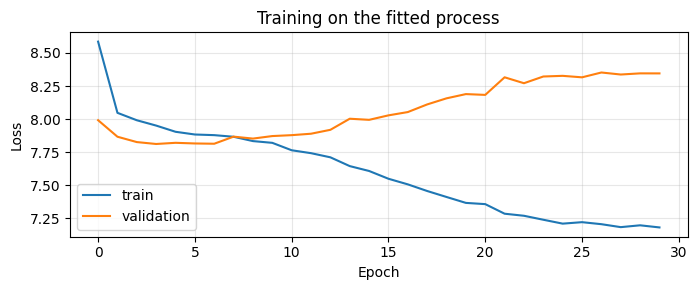

In [9]:
plt.figure(figsize=(7, 3))
plt.plot(history[:, 0], history[:, 1], label="train")
plt.plot(history[:, 0], history[:, 2], label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training on the fitted process")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 4. The estimates recover the cascades

With $\tilde\eta$ and $\tilde\beta$ estimated, the latent genealogy has probabilities — Practical 4's branching probabilities, evaluated at the Transformer's estimates,

$$
\mathbb{P}(\text{parent of } i \text{ is } j) \propto \tilde\eta\, \tilde\beta\, e^{-\tilde\beta (t_i - t_j)},
\qquad
\mathbb{P}(i \text{ is an immigrant}) \propto \hat\mu.
$$

Here $\hat\mu$ stays at its EM value, since the network has no immigration head. One draw assigns each of the 850 extreme days to a cascade, and the largest should line up with known market crises. Every tree is a draw from a fitted model, never an observed fact.

In [10]:
# Practical 4's branching probabilities, now evaluated at the network's estimates
posterior = gx.branching_posterior(days[extreme], float(len(E)), em["mu"],
                                   float(model.eta()), float(model.beta()))
parent_draw = gx.sample_parents(posterior, np.random.default_rng(5))   # one draw, not the truth
events = gx.attributed_events(days[extreme], X[extreme], parent_draw)
events["date"] = E.index[extreme]
sizes = events.groupby("cascade").size()

print("One draw at the Transformer's estimates:", len(sizes), "cascades,",
      int((sizes >= 2).sum()), "with at least two events, largest", int(sizes.max()))
print("\nThe five largest cascades of this draw:")
for c in sizes.sort_values(ascending=False).index[:5]:
    block = events[events["cascade"] == c]
    print(f"  {block['date'].min().date()}  to  {block['date'].max().date()}   {len(block):3d} extreme days")

One draw at the Transformer's estimates: 227 cascades, 117 with at least two events, largest 62

The five largest cascades of this draw:
  2002-06-24  to  2003-04-02    62 extreme days
  2008-09-04  to  2009-07-13    51 extreme days
  2008-09-02  to  2009-02-10    32 extreme days
  2020-02-27  to  2020-06-05    27 extreme days
  2007-07-31  to  2008-04-02    24 extreme days


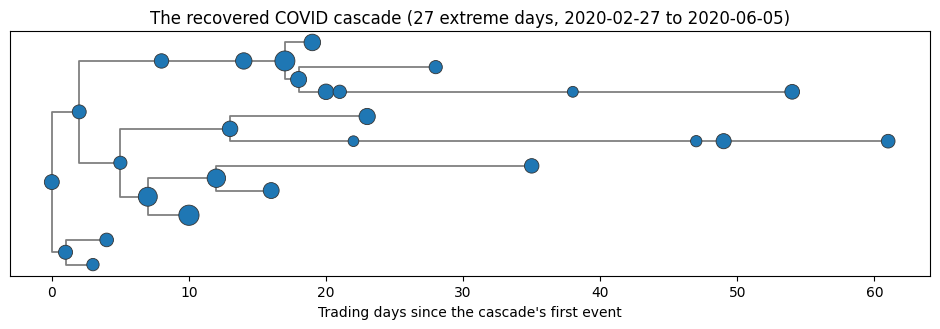

In [11]:
# the cascade that most of March 2020 was assigned to
covid = int(events.loc[(events["date"] >= "2020-03-01") & (events["date"] <= "2020-03-31"), "cascade"].mode()[0])
covid_block = events[events["cascade"] == covid].sort_values("t")

fig, ax = plt.subplots(figsize=(9.5, 3.4))
gx.draw_tree(ax, covid_block["t"].to_numpy() - covid_block["t"].min(), covid_block["r"],
             gx.local_parents(covid_block))
ax.set_xlabel("Trading days since the cascade's first event")
ax.set_title(f"The recovered COVID cascade ({len(covid_block)} extreme days, "
             f"{covid_block['date'].min().date()} to {covid_block['date'].max().date()})")
plt.tight_layout()
plt.show()

## 5. Generate new crises

The trained network is a generator. Sampling one event is:

$\;$ continue with probability $1 - e^{-\tilde\eta A_i}$

→ a waiting time from the first-arrival law

→ an **anchor** from the mixture weights $q_j$, which becomes the parent

→ a direction $\mathrm{vMF}(w_{\mathrm{anchor}}, \tilde\kappa)$

→ a size with rate $g_\psi(w)$, truncated at $\hat u_q(w)$.

We seed it with the first extreme day of the COVID cascade. The three panels show one generated cascade as it grows: the excitation on the timeline, the family tree, and the marks against $\{\hat u_q(w)\, w\}$.

In [12]:
start_block = covid_block                     # YOUR TURN 1 swaps in another cascade
# one real extreme day as the seed, and nothing else
prefix = {"dt": np.zeros(1), "r": np.array([float(start_block["r"].iloc[0])]),
          "W": gx.directions(start_block)[:1], "parent_local": np.array([-1])}

anim_seed = 0
while True:
    anim_seq, anim_steps = gt.sample_continuation(
        model, prefix, np.random.default_rng(anim_seed), max_len=14, record=True)
    if len(anim_steps) >= 8:   # eight steps = nine events
        break
    anim_seed += 1

print("Generated a crisis of", len(anim_seq["dt"]), "events from the extreme day of",
      start_block["date"].iloc[0].date(), "(seed", str(anim_seed) + ")")

Generated a crisis of 14 events from the extreme day of 2020-02-27 (seed 3)


In [13]:
gt.animate_generation(model, anim_seq, anim_steps, surface=gx.surface_of(u_q),
                      labels=("S&P 500", "DAX", "Nikkei"))

### YOUR TURN 1 — Does a bigger cascade generate differently?
---

Try `start_block = events[events["cascade"] == sizes.idxmax()].sort_values("t")` in the sampler cell and re-run the two cells above.

This regenerates the largest recovered cascade, the 2002 unwind, from its first extreme day. Does the generated cascade differ, and should it?

## 6. Diagnostics

We generate 2,500 cascades from the recovered immigrants and compare them with the test cascades, those starting after the split. Three checks:

- **How many events.** The mean generated cascade should match $1/(1 - \tilde\eta) \approx 4$; the test years, calmer than the training ones, run smaller. The table also reports duration, depth and the largest radius.
- **How episodes build.** Forty cumulative severity staircases from each side.
- **How large the events are.** The exceedance PIT of every generated event, as an empirical distribution function; on the diagonal, the sizes follow the fitted radial law.

In [14]:
rng_gen = np.random.default_rng(11)
immigrants = events[(events["parent"] == 0) & (events["t"] < T_train)]
pick = rng_gen.integers(0, len(immigrants), size=2500)
# 2,500 cascades, started from days the model has seen but continued on its own
generated = gt.generate_cascades(model, gx.directions(immigrants)[pick],
                                 immigrants["r"].to_numpy()[pick], rng_gen)

first_t = events.groupby("cascade")["t"].min()
test_seqs = gt.build_sequences(events[events["cascade"].isin(first_t.index[first_t >= T_train])])

gen_sizes = np.array([len(s["dt"]) for s in generated])
print("Mean cascade size | generated:", f"{gen_sizes.mean():.2f}",
      "| 1 / (1 - eta~) =", f"{1.0 / (1.0 - float(model.eta())):.2f}",
      "| test sample:", f"{np.mean([len(s['dt']) for s in test_seqs]):.2f}")
summary = pd.DataFrame({"test sample": gt.summaries(test_seqs).mean(),
                        "generated": gt.summaries(generated).mean()}).T
summary.round(3)

Mean cascade size | generated: 4.05 | 1 / (1 - eta~) = 4.04 | test sample: 3.22


,size,duration,depth,max_r
test sample,3.217,12.522,1.478,5.426
generated,4.046,18.004,1.545,5.368


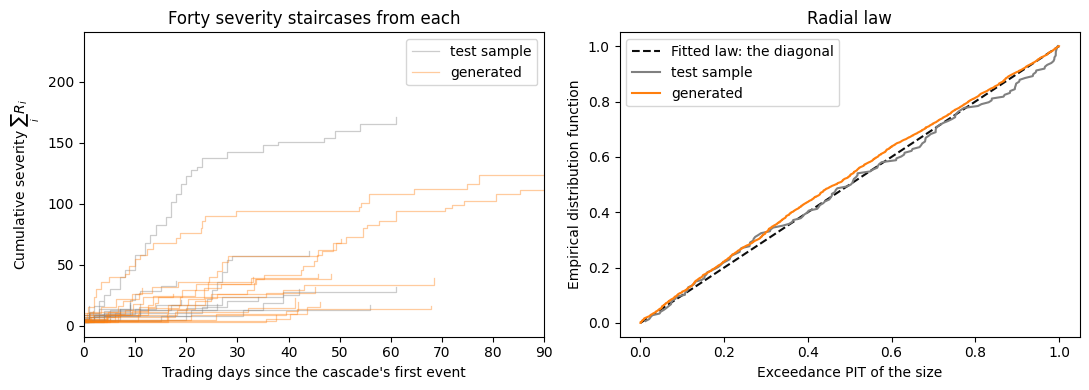

In [15]:
R_gen = np.concatenate([s["r"] for s in generated])
W_gen = np.vstack([s["W"] for s in generated])
u_gen = gx.exceedance_pit(g_ml, W_gen, R_gen, u_q)   # uniform if the sizes follow the fitted law
u_test = gx.exceedance_pit(g_ml, W[m_test], R[m_test], u_q)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for group, colour, label in ((test_seqs, "0.5", "test sample"), (generated, "C1", "generated")):
    for k, s in enumerate(group[:40]):
        t = np.cumsum(s["dt"])
        axes[0].step(t - t[0], np.cumsum(s["r"]), where="post", color=colour, lw=0.9, alpha=0.4,
                     label=label if k == 0 else None)
axes[0].set_xlim(0, 90)
axes[0].set_xlabel("Trading days since the cascade's first event")
axes[0].set_ylabel(r"Cumulative severity $\sum_i R_i$")
axes[0].set_title("Forty severity staircases from each")
axes[0].legend()

axes[1].plot([0, 1], [0, 1], color="0.05", ls="--", label="Fitted law: the diagonal")
for u, colour, label in ((u_test, "0.5", "test sample"), (u_gen, "C1", "generated")):
    u_sorted = np.sort(np.clip(u, 0.0, 1.0))
    axes[1].plot(u_sorted, np.arange(1, len(u_sorted) + 1) / len(u_sorted), color=colour, label=label)
axes[1].set_xlabel("Exceedance PIT of the size")
axes[1].set_ylabel("Empirical distribution function")
axes[1].set_title("Radial law")
axes[1].legend()
plt.tight_layout()
plt.show()

### YOUR TURN 2 — Which cascade holds your crisis?
---

Fill in any date between 1988 and 2026. The cell finds the recovered cascade containing the nearest extreme day and draws its tree.

In [ ]:
# --- Exercise: find a crisis and draw its cascade ---

date = ...               # in quotes, e.g. "2008-09-15", "2011-08-08", "2024-08-05"

target = pd.Timestamp(date)
idx = int(np.argmin(np.abs(events["date"] - target)))
block = events[events["cascade"] == int(events["cascade"].iloc[idx])].sort_values("t")
print("Nearest extreme day:", events["date"].iloc[idx].date(), "| its cascade runs",
      block["date"].min().date(), "to", block["date"].max().date(), "|", len(block), "events")

fig, ax = plt.subplots(figsize=(9, 3))
gx.draw_tree(ax, block["t"].to_numpy() - block["t"].min(), block["r"], gx.local_parents(block))
ax.set_xlabel("Trading days since the cascade's first event")
plt.tight_layout()
plt.show()